In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# ==============================
# 2. LOAD DATA
# ==============================
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "train_FD001.csv"

df = pd.read_csv(DATA_PATH)
print("✅ Data loaded")
df.head()

✅ Data loaded


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


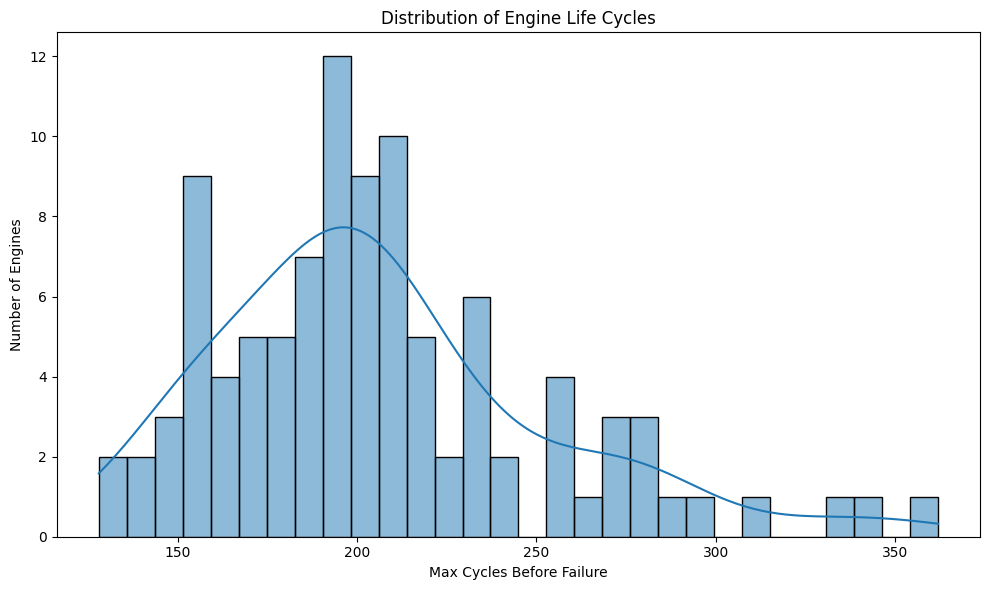

In [3]:
# ==============================
# 3. ENGINE LIFETIME ANALYSIS
# ==============================
engine_life = df.groupby("engine_id")["cycle"].max()

plt.figure(figsize=(10, 6))
sns.histplot(engine_life, bins=30, kde=True)
plt.title("Distribution of Engine Life Cycles")
plt.xlabel("Max Cycles Before Failure")
plt.ylabel("Number of Engines")
plt.tight_layout()
plt.show()

Dead sensors (near-zero variance): ['sensor_1', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5', 'sensor_6']
Live sensors: ['sensor_15', 'sensor_8', 'sensor_13', 'sensor_21', 'sensor_20', 'sensor_11', 'sensor_2', 'sensor_12', 'sensor_7', 'sensor_17', 'sensor_3', 'sensor_4', 'sensor_14', 'sensor_9']


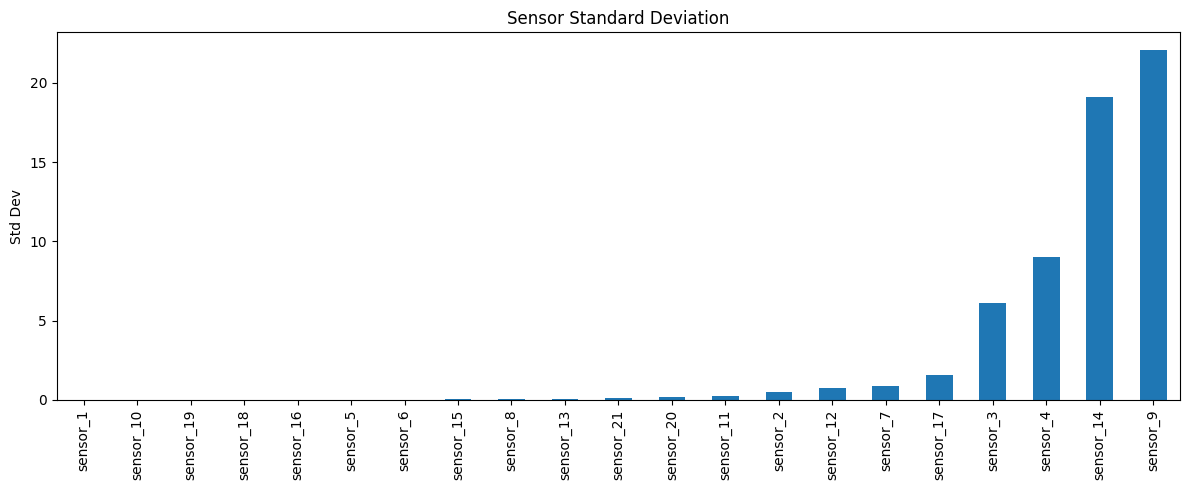

In [4]:
# ==============================
# 4. SENSOR VARIANCE ANALYSIS 
# ==============================
sensor_cols = [col for col in df.columns if col.startswith("sensor")]
sensor_std = df[sensor_cols].std().sort_values()

# Identify dead sensors upfront so all later plots can exclude them
dead_sensors = sensor_std[sensor_std < 0.01].index.tolist()
live_sensors = sensor_std[sensor_std >= 0.01].index.tolist()

print("Dead sensors (near-zero variance):", dead_sensors)
print("Live sensors:", live_sensors)

plt.figure(figsize=(12, 5))
sensor_std.plot(kind="bar")
plt.title("Sensor Standard Deviation")
plt.ylabel("Std Dev")
plt.tight_layout()
plt.show()

Sensors selected for trend plots: ['sensor_7', 'sensor_17', 'sensor_3', 'sensor_4', 'sensor_14', 'sensor_9']


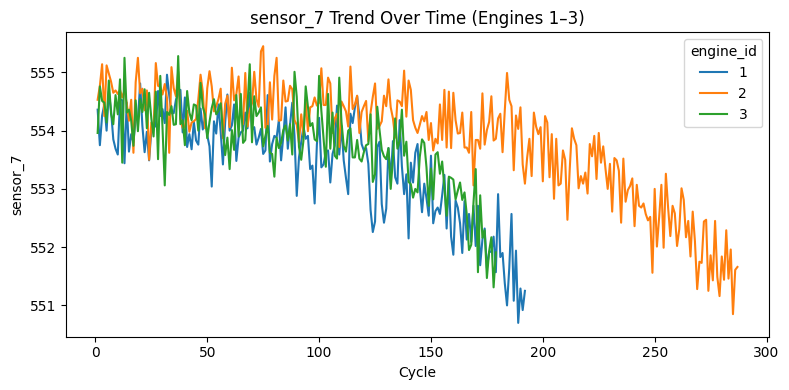

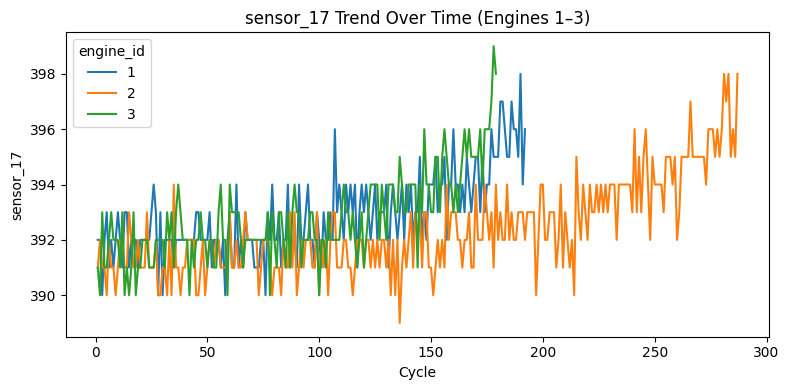

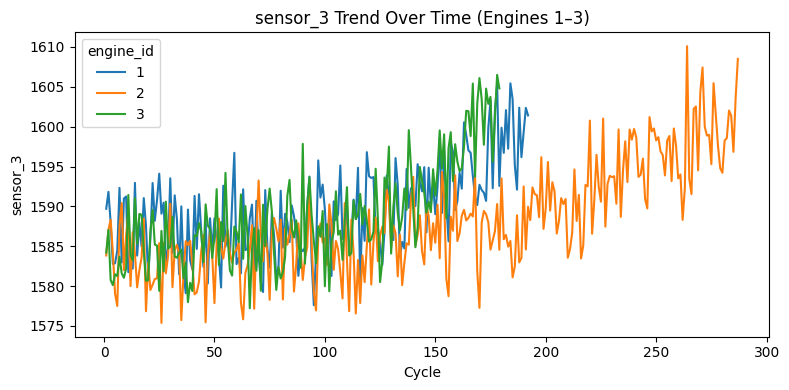

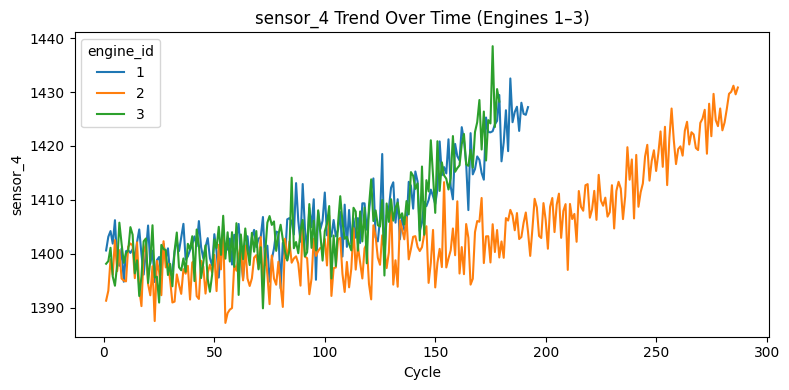

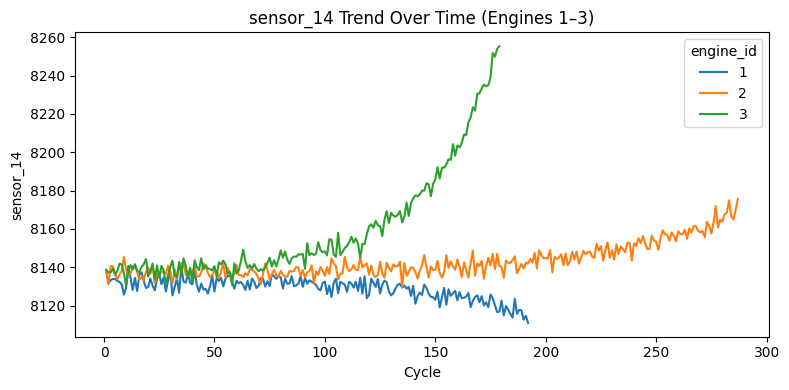

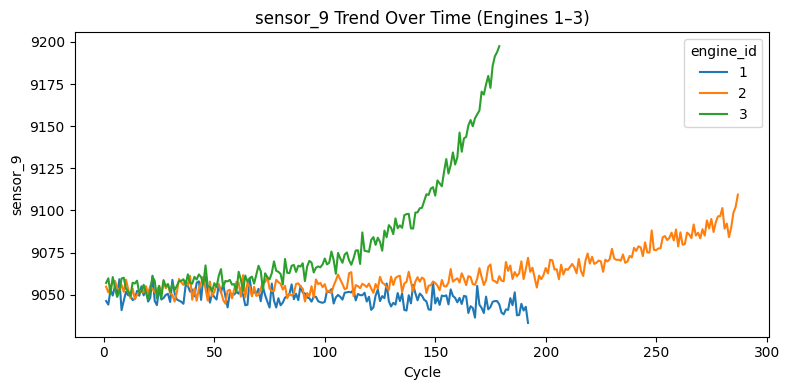

In [5]:
# ==============================
# 5. SENSOR TRENDS OVER TIME  ← fixed pivot + better sensor selection
# ==============================
sample_engines = df[df["engine_id"] <= 3]

# Use top informative sensors by variance, not hardcoded ones
top_sensors = sensor_std[sensor_std >= 0.01].tail(6).index.tolist()
print("Sensors selected for trend plots:", top_sensors)

for sensor in top_sensors:
    # pivot_table is safe against duplicate index errors
    pivot = sample_engines.pivot_table(
        index="cycle", columns="engine_id", values=sensor, aggfunc="mean"
    )
    pivot.plot(figsize=(8, 4))
    plt.title(f"{sensor} Trend Over Time (Engines 1–3)")
    plt.xlabel("Cycle")
    plt.ylabel(sensor)
    plt.tight_layout()
    plt.show()

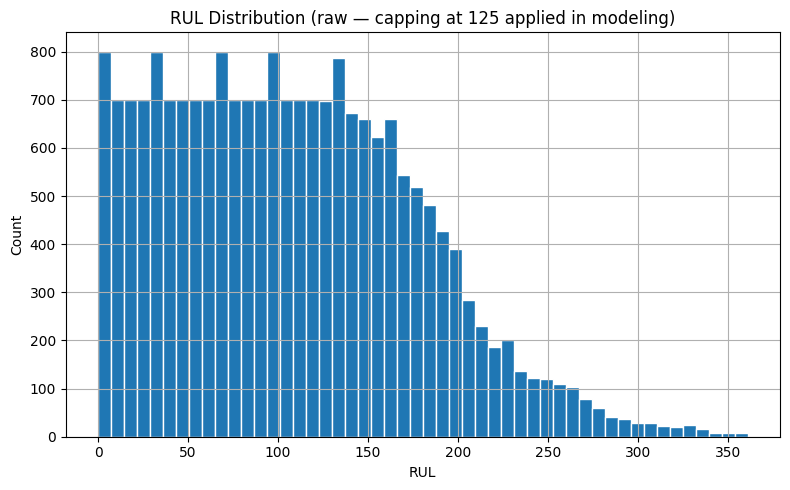

In [6]:
# ==============================
# 6. RUL DISTRIBUTION
# ==============================
plt.figure(figsize=(8, 5))
df["RUL"].hist(bins=50, edgecolor="white")
plt.title("RUL Distribution (raw — capping at 125 applied in modeling)")
plt.xlabel("RUL")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

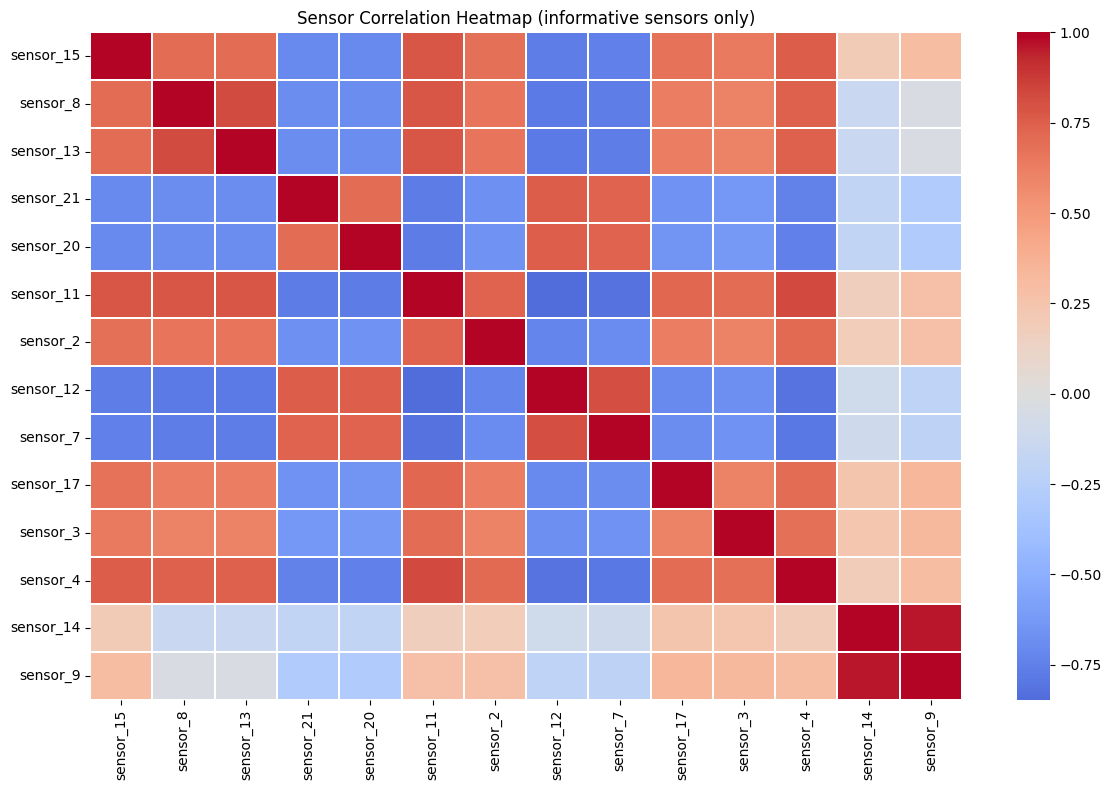

In [7]:
# ==============================
# 7. CORRELATION HEATMAP (live sensors only)  ← excludes dead sensors
# ==============================
plt.figure(figsize=(12, 8))
sns.heatmap(
    df[live_sensors].corr(),
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.3
)
plt.title("Sensor Correlation Heatmap (informative sensors only)")
plt.tight_layout()
plt.show()

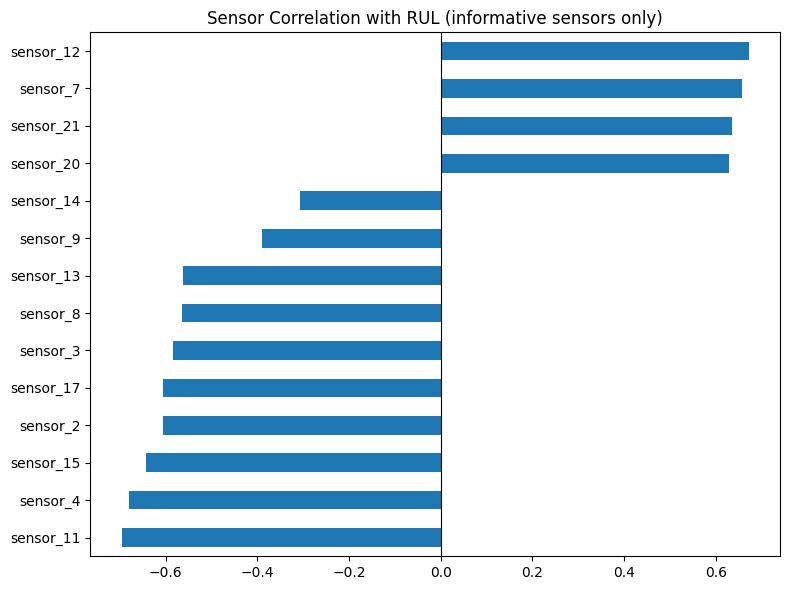

In [8]:
# ==============================
# 8. FEATURE vs TARGET CORRELATION
# ==============================
corr_with_rul = df[live_sensors + ["RUL"]].corr(numeric_only=True)["RUL"].drop("RUL").sort_values()

plt.figure(figsize=(8, 6))
corr_with_rul.plot(kind="barh")
plt.title("Sensor Correlation with RUL (informative sensors only)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

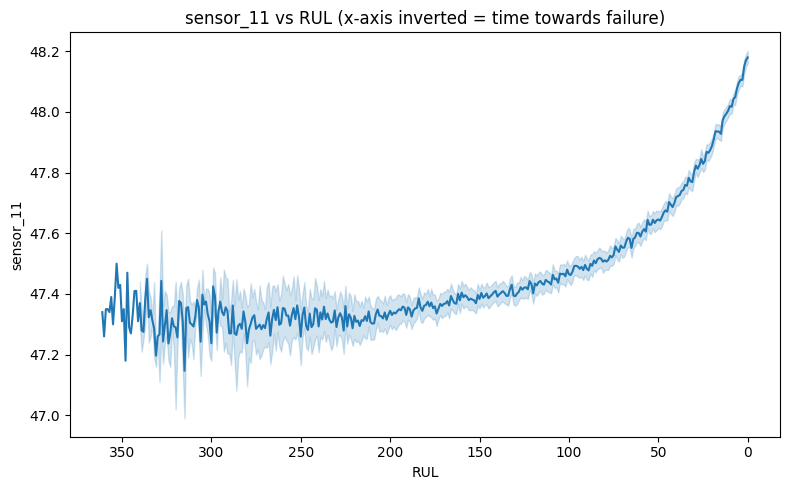

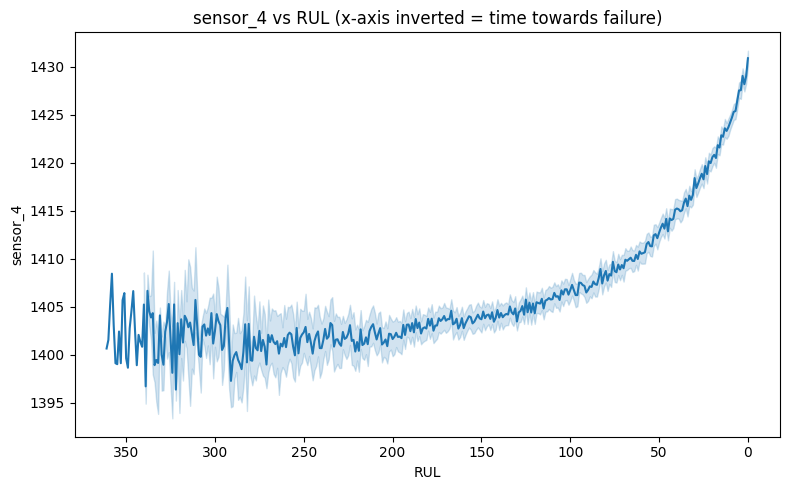

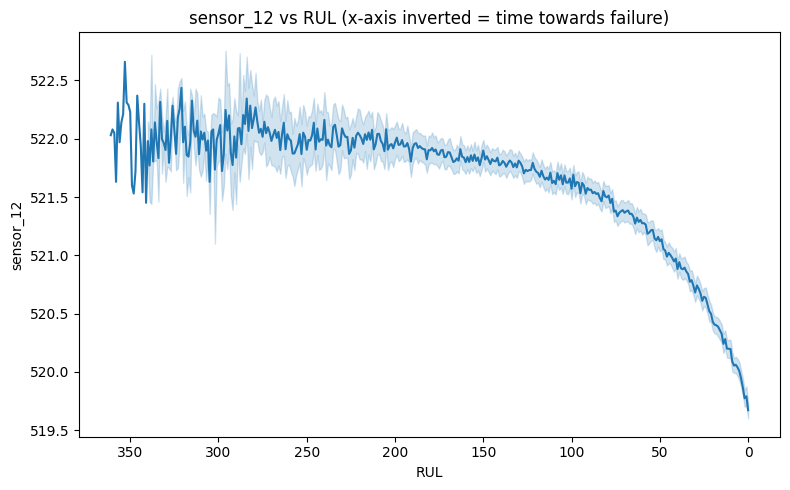

In [9]:
# ==============================
# 9. SENSOR vs RUL TREND
# ==============================
# Plot top 3 most RUL-correlated sensors
top_corr_sensors = corr_with_rul.abs().sort_values(ascending=False).head(3).index.tolist()

for sensor in top_corr_sensors:
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=df, x="RUL", y=sensor)
    plt.gca().invert_xaxis()
    plt.title(f"{sensor} vs RUL (x-axis inverted = time towards failure)")
    plt.tight_layout()
    plt.show()

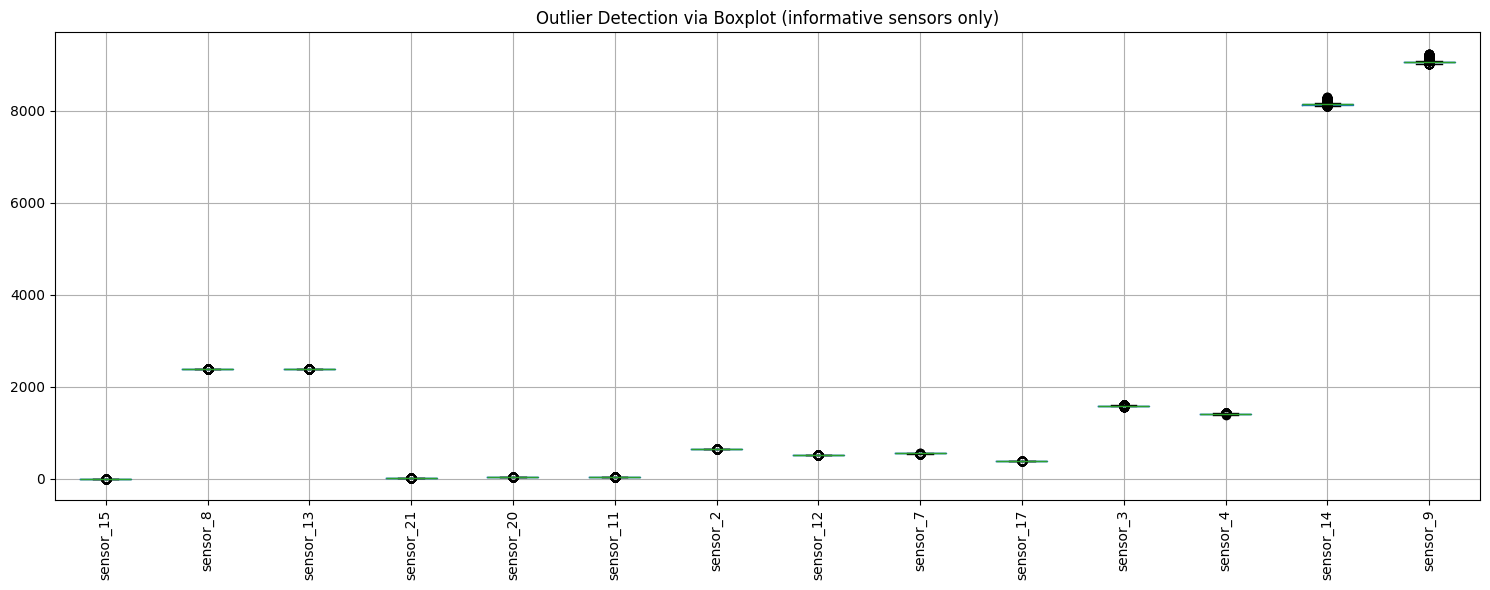

In [10]:
# ==============================
# 10. OUTLIER VISUALIZATION (live sensors only)
# ==============================
plt.figure(figsize=(15, 6))
df[live_sensors].boxplot()
plt.xticks(rotation=90)
plt.title("Outlier Detection via Boxplot (informative sensors only)")
plt.tight_layout()
plt.show()

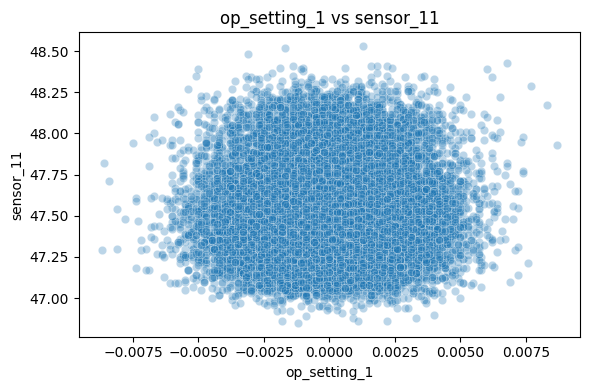

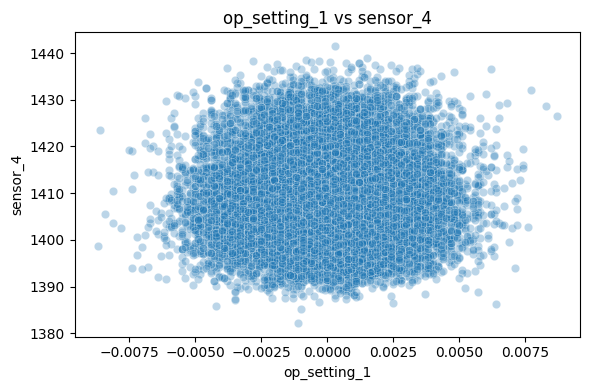

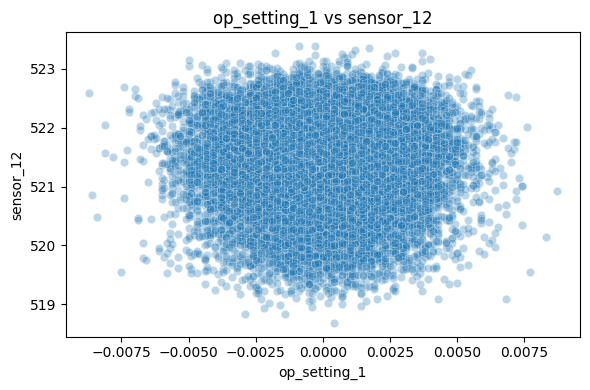

In [11]:
# ==============================
# 11. OPERATING CONDITIONS EFFECT
# ==============================
# FD001 is a single operating condition dataset — op_setting_3 is constant.
# Only op_setting_1 and op_setting_2 vary (slightly).
for sensor in top_corr_sensors:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x="op_setting_1", y=sensor, alpha=0.3)
    plt.title(f"op_setting_1 vs {sensor}")
    plt.tight_layout()
    plt.show()